In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tensorboard.backend.event_processing import event_accumulator
from transformers import CanineTokenizer

## Freezing the pretrained transformer compared to finetuning it

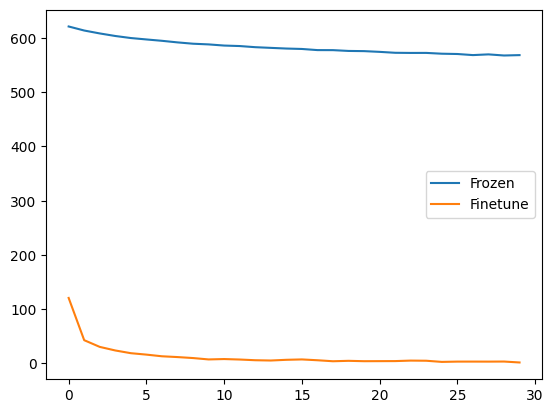

In [23]:
ea = event_accumulator.EventAccumulator("runs/pretrained_frozen")
ea.Reload()
step = [x.step for x in ea.Scalars("Loss/train")]
pretrained_frozen_loss = [x.value for x in ea.Scalars("Loss/train")]
pretrained_frozen_f1 = [x.value for x in ea.Scalars("Metrics/f1")]

ea = event_accumulator.EventAccumulator("runs/finetune")
ea.Reload()
finetune_loss = [x.value for x in ea.Scalars("Loss/train")][:30]
finetune_f1 = [x.value for x in ea.Scalars("Metrics/f1")][:30]
plt.plot(step, pretrained_frozen_loss, label="Frozen")
plt.plot(step, finetune_loss, label="Finetune")
plt.legend()
plt.show()

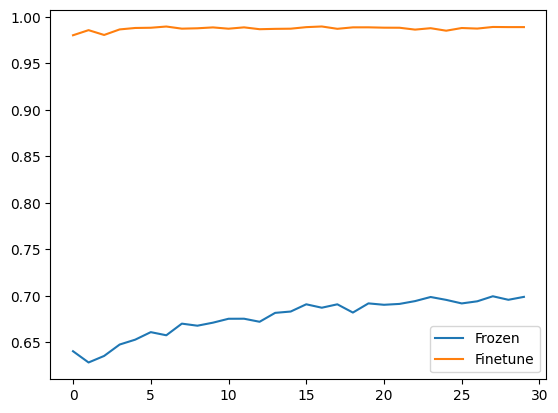

In [26]:
plt.plot(step, pretrained_frozen_f1, label="Frozen")
plt.plot(step, finetune_f1, label="Finetune")
plt.legend()
plt.show()

Freezing the pretrained transformer layer allows for 2x faster training as the backpropogation is minimized, but it suffers a heavy reduction in accuracy and f1, making the extra training time required to fine-tune the pretrained part justified.

## Leave one family out cross-validation

In [2]:
dga_dataset = pd.read_csv("../../data/dga_data.csv")
dga_dataset["isDGA_flag"] = dga_dataset["isDGA"].apply(lambda x: int(x == "dga"))

tokenizer = CanineTokenizer.from_pretrained("google/canine-c")
encodings = tokenizer(list(dga_dataset["domain"].astype(str)), padding="max_length", truncation=True, max_length=64)

X = list(zip(encodings["input_ids"], encodings["attention_mask"], dga_dataset["subclass"]))
y = dga_dataset["isDGA_flag"].to_numpy()

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
families = np.unique(dga_dataset[dga_dataset["isDGA"] == "dga"]["subclass"])
print(families)

['bamital' 'cryptolocker' 'gameoverdga' 'goz' 'necurs' 'newgoz' 'nivdort']


In [3]:
model = torch.load("model.pth", weights_only=False, map_location=torch.device("cpu"))
model.eval()
baseline_f1 = []

for family in families:
    X_test_ids = []
    X_test_atn = []
    y_test_ids = []
    for i, row in enumerate(X_test):
        if row[2] == family:
            X_test_ids.append(row[0])
            X_test_atn.append(row[1])
            y_test_ids.append(y_test[i])

    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test_ids, dtype=torch.long),
                      torch.tensor(X_test_atn, dtype=torch.long),
                      torch.tensor(y_test_ids, dtype=torch.long)),
        batch_size=128
    )
    all_preds = np.array([])
    all_labels = np.array([])

    for input_ids, attention_mask, labels in test_loader:
        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        all_preds = np.append(all_preds, out.logits.argmax(1).numpy())
        all_labels = np.append(all_labels, labels)
    baseline_f1.append(f1_score(all_labels, all_preds))

In [7]:
lofo_f1 = []
for family in families:
    ea = event_accumulator.EventAccumulator(f"runs/{family}")
    ea.Reload()
    lofo_f1.append(ea.Scalars(f"Test/{family}_f1")[0].value)

In [14]:
data = {"Family": families, "Baseline_f1":baseline_f1, "LOFO_f1": lofo_f1}
results_df = pd.DataFrame.from_dict(data)
results_df["Generalisation Gap"] = results_df["Baseline_f1"] - results_df["LOFO_f1"]
results_df = results_df.sort_values(by="Generalisation Gap", ascending=False)
print(results_df)

         Family  Baseline_f1   LOFO_f1  Generalisation Gap
6       nivdort     0.996635  0.002362            0.994273
4        necurs     0.935881  0.856417            0.079464
1  cryptolocker     0.988498  0.985001            0.003496
0       bamital     1.000000  1.000000            0.000000
3           goz     0.999193  0.999429           -0.000236
5        newgoz     0.998361  1.000000           -0.001639
2   gameoverdga     0.997943  1.000000           -0.002057


All families except nivdort do not suffer a high reduction in f1 when all data from that subclass are removed from the training and validation data. This means that the model has high generalisability to unseen dga algorithms, except for the nivdort subclass.